# RESULTS

In this file we are going to evaluate the results. We will start by checking the performance of each group of features regarding the predictions we achieve with all the combinations of them, and looking at what metrics each grup increases. Based on that we will define our final group of features, so our final model.

The last step will consist on evaluate this model by checking the feature importance, the shap values and finally showing some examples of the performance of the model, and the general performance in both the hard onset countries and the protracted ones. 

In [4]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, roc_curve, precision_recall_curve, f1_score, roc_auc_score, average_precision_score

In [5]:
import json

# 1. Define the exact path where the file was saved
file_path = "results/experiments_map.json"

# 2. Open the file in read mode ('r') and load it
with open(file_path, "r", encoding="utf-8") as f:
    experiments_map = json.load(f)

experiments_map["Random Benchmark (Stratified)"] = "benchmark_random"
experiments_map["Optimal"] = "optimal"

# Perfect! Your dictionary is now fully recovered
print(f"Experiments map loaded successfully. Total experiments: {len(experiments_map)}")

Experiments map loaded successfully. Total experiments: 109


### 1. RESULTS ANALYSIS BASED ON FEATURES GROUPS

In [6]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import (
    roc_curve, precision_recall_curve, f1_score, roc_auc_score,
    precision_score, recall_score, classification_report, average_precision_score
)

def evaluate_experiments(plots_filter, df_master, threshold_05=False, results_folder="results", experiments_map=None):
    """
    Evaluates ML experiments, plots 6 curves (Global, Protracted, Hard Onset),
    calculates subgroup metrics, and displays ONE single global legend at the bottom without overlapping.
    """
    comparison_results = []
    
    # --- PREPARAR LAS 6 GRÁFICAS ---
    # Aumentamos bastante el alto total (de 27 a 35) para que quepan todos tus experimentos de sobra
    fig, axes = plt.subplots(3, 2, figsize=(18, 35))
    ax_roc_glob, ax_pr_glob = axes[0]
    ax_roc_pro, ax_pr_pro = axes[1]
    ax_roc_hard, ax_pr_hard = axes[2]

    for name, prefix in experiments_map.items():
        if name not in plots_filter:
            continue

        pred_file = os.path.join(results_folder, f"{prefix}_predictions.csv")
        feat_file = os.path.join(results_folder, f"{prefix}_feature_importance.csv")
        
        if not os.path.exists(pred_file):
            continue
            
        print(f"🔄 Processing: {name}...")
        
        # 1. Cargar predicciones
        df_preds = pd.read_csv(pred_file)
        
        # Arreglar nombres de índices si Pandas los leyó sin nombre
        if 'Unnamed: 0' in df_preds.columns and 'Unnamed: 1' in df_preds.columns:
            df_preds = df_preds.rename(columns={'Unnamed: 0': 'iso3', 'Unnamed: 1': 'month'})
        
        # Convertir mes a formato fecha
        if 'month' in df_preds.columns:
            df_preds['month'] = pd.to_datetime(df_preds['month'], errors='coerce')

        all_y_true = df_preds["y_true"]
        all_y_prob = df_preds["y_prob"]

        # --- UMBRAL ÓPTIMO (GLOBAL) ---
        if threshold_05:
            current_threshold = 0.5
        else:
            precisions, recalls, thresholds_pr = precision_recall_curve(all_y_true, all_y_prob)
            f1_scores = np.divide(
                2 * (precisions * recalls),
                (precisions + recalls),
                out=np.zeros_like(precisions),
                where=(precisions + recalls) != 0
            )
            best_idx = np.argmax(f1_scores[:-1])
            current_threshold = thresholds_pr[best_idx]

        df_preds['y_pred'] = (all_y_prob >= current_threshold).astype(int)

        # Global metrics
        f1 = f1_score(all_y_true, df_preds['y_pred'])
        prec = precision_score(all_y_true, df_preds['y_pred'], zero_division=0)
        rec = recall_score(all_y_true, df_preds['y_pred'])
        roc_auc = roc_auc_score(all_y_true, all_y_prob)
        num_features = len(pd.read_csv(feat_file)) if os.path.exists(feat_file) else 0

        # --- 2. CRUCE DE DATOS CON EL MASTER PARA SACAR LOS SUBGRUPOS ---
        pro_prec, pro_rec, pro_f1, pro_roc_auc = np.nan, np.nan, np.nan, np.nan
        hard_prec, hard_rec, hard_f1, hard_roc_auc = np.nan, np.nan, np.nan, np.nan
        has_subgroups = False
        
        if 'is_protracted' not in df_preds.columns:
            if 'iso3' in df_preds.columns and 'month' in df_preds.columns:
                df_preds = pd.merge(df_preds, df_master[['iso3', 'month', 'is_protracted']], on=['iso3', 'month'], how='inner')

        if 'is_protracted' in df_preds.columns and not df_preds['is_protracted'].isna().all():
            has_subgroups = True
        
        # --- PLOT: GLOBAL (Guardamos las etiquetas AQUÍ) ---
        fpr, tpr, _ = roc_curve(all_y_true, all_y_prob)
        ax_roc_glob.plot(fpr, tpr, lw=2, label=f'{name} (AUC = {roc_auc:.3f})')
        
        prec_curve, rec_curve, _ = precision_recall_curve(all_y_true, all_y_prob)
        avg_prec = average_precision_score(all_y_true, all_y_prob)
        ax_pr_glob.plot(rec_curve, prec_curve, lw=2, label=f'{name} (AP = {avg_prec:.3f})')

        if has_subgroups:
            # --- PROTRACTED (1) ---
            pro_mask = df_preds['is_protracted'] == 1
            if pro_mask.sum() > 0:
                y_t_pro = df_preds.loc[pro_mask, 'y_true']
                y_p_pro = df_preds.loc[pro_mask, 'y_prob']
                y_pred_pro = df_preds.loc[pro_mask, 'y_pred']
                
                pro_prec = precision_score(y_t_pro, y_pred_pro, zero_division=0)
                pro_rec = recall_score(y_t_pro, y_pred_pro, zero_division=0)
                pro_f1 = f1_score(y_t_pro, y_pred_pro, zero_division=0)
                
                if len(np.unique(y_t_pro)) > 1:
                    pro_roc_auc = roc_auc_score(y_t_pro, y_p_pro)
                    fpr_p, tpr_p, _ = roc_curve(y_t_pro, y_p_pro)
                    ax_roc_pro.plot(fpr_p, tpr_p, lw=2) 
                    
                    prec_p, rec_p, _ = precision_recall_curve(y_t_pro, y_p_pro)
                    ax_pr_pro.plot(rec_p, prec_p, lw=2)

            # --- HARD ONSET (0) ---
            hard_mask = df_preds['is_protracted'] == 0
            if hard_mask.sum() > 0:
                y_t_hard = df_preds.loc[hard_mask, 'y_true']
                y_p_hard = df_preds.loc[hard_mask, 'y_prob']
                y_pred_hard = df_preds.loc[hard_mask, 'y_pred']
                
                hard_prec = precision_score(y_t_hard, y_pred_hard, zero_division=0)
                hard_rec = recall_score(y_t_hard, y_pred_hard, zero_division=0)
                hard_f1 = f1_score(y_t_hard, y_pred_hard, zero_division=0)
                
                if len(np.unique(y_t_hard)) > 1:
                    hard_roc_auc = roc_auc_score(y_t_hard, y_p_hard)
                    fpr_h, tpr_h, _ = roc_curve(y_t_hard, y_p_hard)
                    ax_roc_hard.plot(fpr_h, tpr_h, lw=2)
                    
                    prec_h, rec_h, _ = precision_recall_curve(y_t_hard, y_p_hard)
                    ax_pr_hard.plot(rec_h, prec_h, lw=2)

        # Guardar en tabla
        comparison_results.append({
            'Experiment': name,
            'Thr': round(current_threshold, 3),
            'Glob F1': round(f1, 3),
            'Glob P': round(prec, 3),
            'Glob R': round(rec, 3),
            'Glob AUC': round(roc_auc, 3),
            'Pro F1': round(pro_f1, 3) if pd.notna(pro_f1) else '-',
            'Pro P': round(pro_prec, 3) if pd.notna(pro_prec) else '-',
            'Pro R': round(pro_rec, 3) if pd.notna(pro_rec) else '-',
            'Pro AUC': round(pro_roc_auc, 3) if pd.notna(pro_roc_auc) else '-',
            'Hard F1': round(hard_f1, 3) if pd.notna(hard_f1) else '-',
            'Hard P': round(hard_prec, 3) if pd.notna(hard_prec) else '-',
            'Hard R': round(hard_rec, 3) if pd.notna(hard_rec) else '-',
            'Hard AUC': round(hard_roc_auc, 3) if pd.notna(hard_roc_auc) else '-',
            'Feats': num_features
        })

    # ============================================================
    # FORMATO ESTÉTICO DE LAS 6 GRÁFICAS
    # ============================================================
    plot_configs = [
        (ax_roc_glob, ax_pr_glob, 'GLOBAL'),
        (ax_roc_pro, ax_pr_pro, 'PROTRACTED CRISES (is_protracted = 1)'),
        (ax_roc_hard, ax_pr_hard, 'HARD ONSET CRISES (is_protracted = 0)')
    ]
    
    for ax_roc, ax_pr, title in plot_configs:
        ax_roc.plot([0, 1], [0, 1], color='navy', linestyle='--', alpha=0.5)
        ax_roc.set_xlim([0.0, 1.0])
        ax_roc.set_ylim([0.0, 1.05])
        ax_roc.set_title(f'{title}: ROC Curve', fontsize=14, fontweight='bold')
        ax_roc.set_xlabel('False Positive Rate', fontsize=11)
        ax_roc.set_ylabel('True Positive Rate', fontsize=11)
        ax_roc.grid(alpha=0.3)

        ax_pr.set_xlim([0.0, 1.0])
        ax_pr.set_ylim([0.0, 1.05])
        ax_pr.set_title(f'{title}: Precision-Recall Curve', fontsize=14, fontweight='bold')
        ax_pr.set_xlabel('Recall', fontsize=11)
        ax_pr.set_ylabel('Precision', fontsize=11)
        ax_pr.grid(alpha=0.3)

    # ============================================================
    # TRUCO MÁGICO V2: LEYENDA SEPARADA TOTALMENTE
    # ============================================================
    handles, labels = ax_roc_glob.get_legend_handles_labels()
    
    # Comprimimos las gráficas en el 75% superior de la imagen (de y=0.25 a y=1.0)
    plt.tight_layout(rect=[0, 0.25, 1, 1])
    
    # Colgamos la leyenda en ese 25% vacío que acabamos de crear abajo
    fig.legend(
        handles, 
        labels, 
        loc='upper center',       # La anclamos desde ARRIBA de la leyenda
        bbox_to_anchor=(0.5, 0.23), # Empezamos a dibujar justo debajo de las gráficas
        ncol=3,                   # Columnas para repartir los 50+ experimentos
        fontsize=9, 
        frameon=True,
        facecolor='#f9f9f9',
        edgecolor='#d3d3d3'
    )

    plt.show()

    # ============================================================
    # IMPRIMIR TABLA DE RESULTADOS
    # ============================================================
    if comparison_results:
        df_results = pd.DataFrame(comparison_results).sort_values(by='Glob F1', ascending=False)
        print("\n" + "#"*160)
        print("FINAL RANKING (SORTED BY GLOBAL F1) - INCLUDES PROTRACTED VS HARD ONSET".center(160))
        print("#"*160)
        print(df_results.to_string(index=False))
    else:
        print("\n❌ No experiments were successfully loaded.")

All the available models that we have, and that we can check their performance are:

In [7]:
models = list(experiments_map.keys())

In [8]:
print(models)

['Only Signals (CERF)', 'Only Signals (CERF) BEST', 'Only INFORM', 'Only INFORM + Only Signals (CERF)', 'Only INFORM + Only Signals (CERF) BEST', 'Only Risk Alerts', 'Only Risk Alerts + Only Signals (CERF)', 'Only Risk Alerts + Only Signals (CERF) BEST', 'Only Risk Alerts + Only INFORM', 'Only Risk Alerts + Only INFORM + Only Signals (CERF)', 'Only Risk Alerts + Only INFORM + Only Signals (CERF) BEST', 'Only Risk Alerts BEST', 'Only Risk Alerts BEST + Only Signals (CERF)', 'Only Risk Alerts BEST + Only Signals (CERF) BEST', 'Only Risk Alerts BEST + Only INFORM', 'Only Risk Alerts BEST + Only INFORM + Only Signals (CERF)', 'Only Risk Alerts BEST + Only INFORM + Only Signals (CERF) BEST', 'Derived Humanitarian Impact', 'Derived Humanitarian Impact + Only Signals (CERF)', 'Derived Humanitarian Impact + Only Signals (CERF) BEST', 'Derived Humanitarian Impact + Only INFORM', 'Derived Humanitarian Impact + Only INFORM + Only Signals (CERF)', 'Derived Humanitarian Impact + Only INFORM + Only 

🔄 Processing: Only Signals (CERF)...
🔄 Processing: Only Signals (CERF) BEST...
🔄 Processing: Only INFORM...
🔄 Processing: Only INFORM + Only Signals (CERF)...
🔄 Processing: Only INFORM + Only Signals (CERF) BEST...
🔄 Processing: Only Risk Alerts...
🔄 Processing: Only Risk Alerts + Only Signals (CERF)...
🔄 Processing: Only Risk Alerts + Only Signals (CERF) BEST...
🔄 Processing: Only Risk Alerts + Only INFORM...
🔄 Processing: Only Risk Alerts + Only INFORM + Only Signals (CERF)...
🔄 Processing: Only Risk Alerts + Only INFORM + Only Signals (CERF) BEST...
🔄 Processing: Only Risk Alerts BEST...
🔄 Processing: Only Risk Alerts BEST + Only Signals (CERF)...
🔄 Processing: Only Risk Alerts BEST + Only Signals (CERF) BEST...
🔄 Processing: Only Risk Alerts BEST + Only INFORM...
🔄 Processing: Only Risk Alerts BEST + Only INFORM + Only Signals (CERF)...
🔄 Processing: Only Risk Alerts BEST + Only INFORM + Only Signals (CERF) BEST...
🔄 Processing: Derived Humanitarian Impact...
🔄 Processing: Derived 

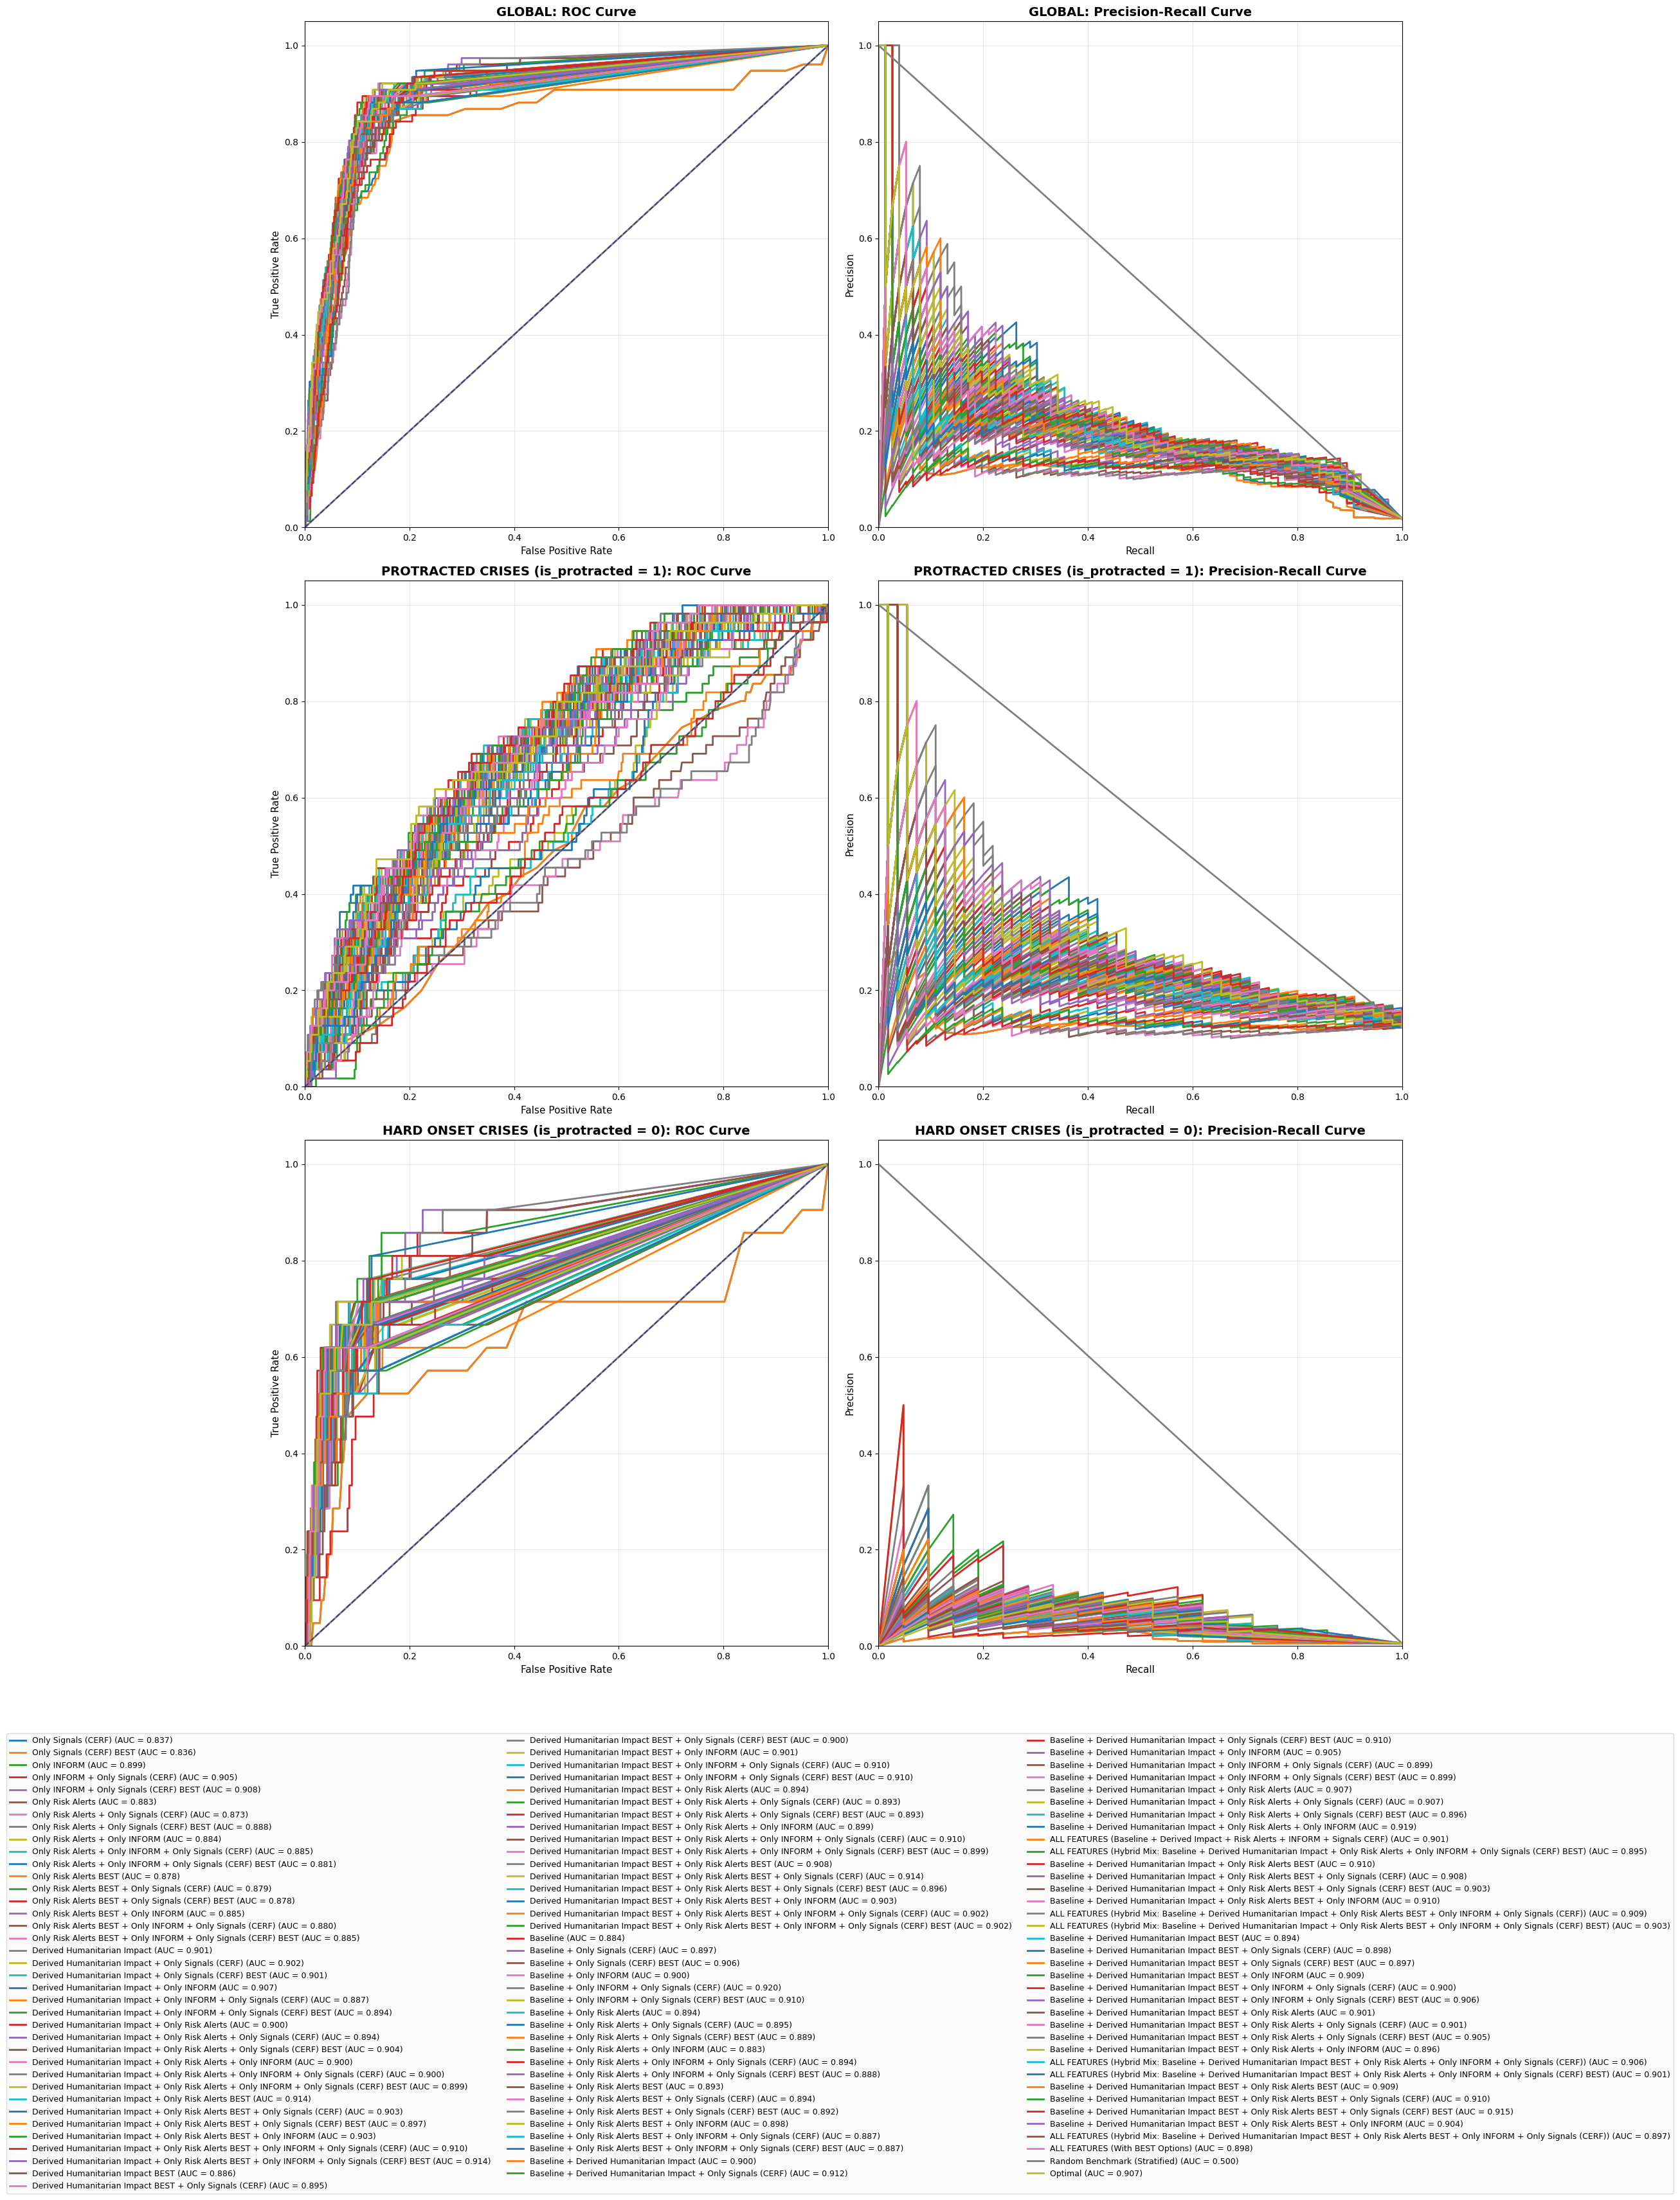


################################################################################################################################################################
                                            FINAL RANKING (SORTED BY GLOBAL F1) - INCLUDES PROTRACTED VS HARD ONSET                                             
################################################################################################################################################################
                                                                                                                        Experiment   Thr  Glob F1  Glob P  Glob R  Glob AUC  Pro F1  Pro P  Pro R  Pro AUC  Hard F1  Hard P  Hard R  Hard AUC  Feats
                                                                                         Derived Humanitarian Impact + Only INFORM 0.791    0.338   0.383   0.303     0.907   0.404  0.390  0.418    0.714    0.000   0.000   0.000     0.814     35
                          

In [9]:
# ==========================================
# CÓMO EJECUTARLO AHORA (¡Súper importante!)
# ==========================================

# 1. Cargas el parquet tú mismo (así si hay un error de ruta te enteras enseguida)
ruta_parquet = "../data_clean/final_data.parquet" # <-- ¡Asegúrate de que la ruta es correcta!
df_original = pd.read_parquet(ruta_parquet)

# 2. Si iso3 y month están en el índice, los pasamos a columnas y aseguramos formato fecha
if 'iso3' not in df_original.columns:
    df_original = df_original.reset_index()
if 'month' in df_original.columns:
    df_original['month'] = pd.to_datetime(df_original['month'], errors='coerce')


evaluate_experiments(
    plots_filter=models, 
    df_master=df_original, # <-- ¡Aquí es donde le pasamos el Parquet ya cargado!
    threshold_05=False, 
    experiments_map=experiments_map
)

### 2. CHOOSING THE FINAL MODEL (FINAL GROUP OF FEATURES)

In [11]:
df = pd.read_parquet("../data_clean/final_data.parquet")

In [12]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import shap
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import f1_score, precision_score, recall_score, roc_auc_score
from panelsplit.cross_validation import PanelSplit

# ==============================================================================
# 0. CONFIGURACIÓN INICIAL
# ==============================================================================
# Tu lista definitiva de variables elegidas
FINAL_FEATURES = ['disp_6m_avg', 'rolling_3m_displacements', 'fatalities', 'HA', 'VU', 'INFORM', 'disp_3m_avg', 'logfat_risk_12', 'lethality_rate', 'acled_disp_score_max', 'monthly_displacement', 'CC', 'acled_disp_score_mean', 'logfat_risk_3']

TARGET_COL = 'target_2m'

# Cargar tu dataset limpio (suponiendo que ya lo tienes leído como df)
# df = pd.read_parquet("data_clean/final_data.parquet")

# ==============================================================================
# 1. PREPARACIÓN DE DATOS
# ==============================================================================
def prepare_final_data(df, features_to_use, target_col='target_2m'):
    df_temp = df.copy()
    
    # Ocultar los últimos 2 meses por país (simulación real)
    last_2_months_mask = df_temp.groupby('iso3').cumcount(ascending=False) < 2
    df_temp[target_col] = df_temp[target_col].astype(float)
    df_temp.loc[last_2_months_mask, target_col] = np.nan

    # Limpieza estricta
    df_model = df_temp[features_to_use + [target_col, 'is_protracted']].dropna()
    
    X = df_model[features_to_use]
    y = df_model[target_col]
    subgroups = df_model['is_protracted'] # Guardamos esto para las métricas finales
    
    return X, y, subgroups

X, y, subgroups = prepare_final_data(df, FINAL_FEATURES, TARGET_COL)
periods = X.index.get_level_values('month')

# ==============================================================================
# 2. VALIDACIÓN (Para obtener métricas reales y ver cuándo dice 1 y 0)
# ==============================================================================
# Instanciamos la estrategia de split que tenías
panel_split = PanelSplit(periods=periods, n_splits=24, test_size=1, gap=1)

# Modelo auxiliar para la validación
clf_cv = RandomForestClassifier(n_estimators=200, max_depth=10, class_weight='balanced', random_state=42, n_jobs=-1)

all_y_true, all_y_prob, all_iso3, all_months, all_subgroups = [], [], [], [], []

for train_idx, test_idx in panel_split.split(X):
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
    
    clf_cv.fit(X_train, y_train)
    probs = clf_cv.predict_proba(X_test)[:, 1]
    
    all_y_true.extend(y_test.values)
    all_y_prob.extend(probs)
    all_iso3.extend(X_test.index.get_level_values('iso3'))
    all_months.extend(X_test.index.get_level_values('month'))
    all_subgroups.extend(subgroups.iloc[test_idx].values)

# Crear DataFrame de evaluación interna (En memoria, sin guardar CSVs molestos)
df_eval = pd.DataFrame({
    'iso3': all_iso3,
    'month': all_months,
    'y_true': all_y_true,
    'y_prob': all_y_prob,
    'is_protracted': all_subgroups
})

# Calcular umbral óptimo global basado en F1
from sklearn.metrics import precision_recall_curve
precisions, recalls, thresholds = precision_recall_curve(df_eval['y_true'], df_eval['y_prob'])
f1_scores = np.divide(2 * (precisions * recalls), (precisions + recalls), out=np.zeros_like(precisions), where=(precisions + recalls) != 0)
best_threshold = thresholds[np.argmax(f1_scores[:-1])]

# Asignar predicciones binarias usando el umbral óptimo
df_eval['y_pred'] = (df_eval['y_prob'] >= best_threshold).astype(int)

# ==============================================================================
# 3. ENTRENAMIENTO DEL MODELO FINAL (100% de los datos para SHAP e Importancia)
# ==============================================================================
print("\n🚀 Entrenando modelo final con el 100% de los datos...")
model_final = RandomForestClassifier(n_estimators=200, max_depth=10, class_weight='balanced', random_state=42, n_jobs=-1)
model_final.fit(X, y)
print("✅ Modelo final entrenado.")


🚀 Entrenando modelo final con el 100% de los datos...
✅ Modelo final entrenado.


### 3. EVALUATING THE FINAL MODEL

#### 3.1 METRICS EVALUATION

In [13]:
def print_subgroup_metrics(df, thr):
    print(f" Umbral Óptimo Aplicado: {thr:.3f}\n" + "-"*50)
    
    subsets = {
        'GLOBAL': df,
        'PROTRACTED (is_protracted = 1)': df[df['is_protracted'] == 1],
        'HARD ONSET (is_protracted = 0)': df[df['is_protracted'] == 0]
    }
    
    for name, sub_df in subsets.items():
        if len(sub_df) == 0: continue
        y_t = sub_df['y_true']
        y_p = sub_df['y_pred']
        y_prob = sub_df['y_prob']
        
        f1 = f1_score(y_t, y_p, zero_division=0)
        prec = precision_score(y_t, y_p, zero_division=0)
        rec = recall_score(y_t, y_p, zero_division=0)
        auc = roc_auc_score(y_t, y_prob) if len(np.unique(y_t)) > 1 else np.nan
        
        print(f"📊 {name}:")
        print(f"   F1-Score: {f1:.3f} | Precision: {prec:.3f} | Recall: {rec:.3f} | AUC: {auc:.3f}\n")

print_subgroup_metrics(df_eval, best_threshold)

 Umbral Óptimo Aplicado: 0.800
--------------------------------------------------
📊 GLOBAL:
   F1-Score: 0.329 | Precision: 0.317 | Recall: 0.342 | AUC: 0.907

📊 PROTRACTED (is_protracted = 1):
   F1-Score: 0.388 | Precision: 0.329 | Recall: 0.473 | AUC: 0.723

📊 HARD ONSET (is_protracted = 0):
   F1-Score: 0.000 | Precision: 0.000 | Recall: 0.000 | AUC: 0.811



#### 3.2 FEATURE IMPORTANCE AND SHAP VALUES

In [14]:
df_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': model_final.feature_importances_
}).sort_values(by='importance', ascending=False)

print("🏆 IMPORTANCIA DE LAS VARIABLES:")
display(df_importance)

🏆 IMPORTANCIA DE LAS VARIABLES:


,feature,importance
7,logfat_risk_12,0.186530
13,logfat_risk_3,0.185845
0,disp_6m_avg,0.163136
2,fatalities,0.083654
1,rolling_3m_displacements,0.065614
6,disp_3m_avg,0.059562
4,VU,0.047071
5,INFORM,0.046504
3,HA,0.044459
8,lethality_rate,0.034263


Calculando SHAP values...
Formato nuevo de SHAP detectado (Matriz 3D).
Generando el gráfico Summary Plot...


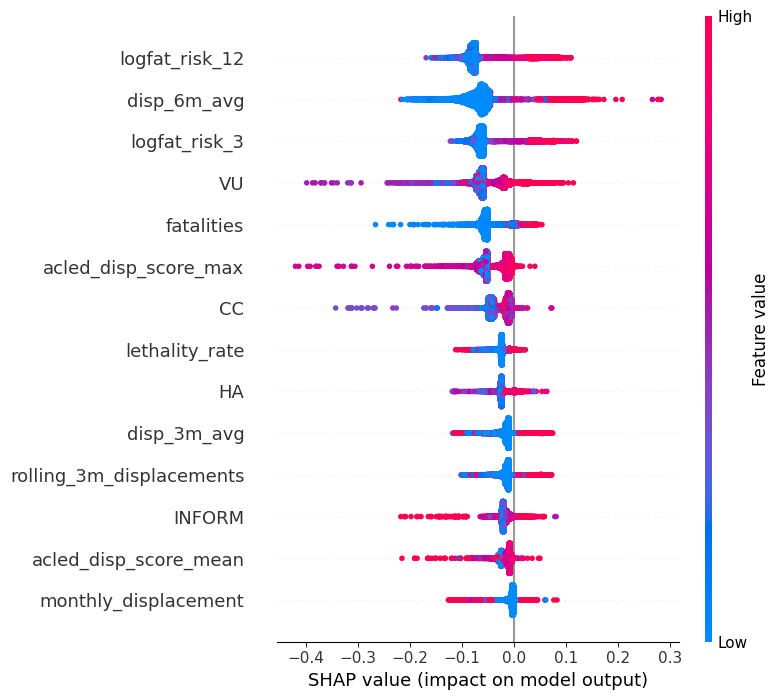

In [16]:
import numpy as np

# 1. Crear el explicador específico para árboles (Random Forest)
explainer = shap.TreeExplainer(model_final)

# 2. Calcular los valores shap para tu matriz X
print("Calculando SHAP values...")
shap_values = explainer.shap_values(X)

# 3. Extraer la clase positiva (1) de forma segura
# Comprobamos la estructura que nos ha devuelto la librería SHAP
if isinstance(shap_values, list):
    # Formato antiguo: Lista de arrays
    print("Formato antiguo de SHAP detectado.")
    shap_values_positiva = shap_values[1]
elif isinstance(shap_values, np.ndarray) and len(shap_values.shape) == 3:
    # Formato nuevo: Matriz 3D (n_samples, n_features, n_classes)
    print("Formato nuevo de SHAP detectado (Matriz 3D).")
    # Todas las filas (:), todas las columnas (:), índice de la clase positiva (1)
    shap_values_positiva = shap_values[:, :, 1]
else:
    # Por si devuelve una matriz 2D plana directamente (en algunos modelos de scikit-learn)
    print("Formato 2D detectado.")
    shap_values_positiva = shap_values

# 4. Gráfico Summary Plot (Muestra el impacto positivo/negativo de las variables)
print("Generando el gráfico Summary Plot...")
shap.summary_plot(shap_values_positiva, X)

#### 3.3 SHOWING THE RESULTS

In [17]:
# Ver casos donde el modelo predice una crisis (y_pred = 1) y acertó (True Positive)
print("🔥 FALSAS ALARMAS O ACIERTOS CRÍTICOS:")
display(df_eval[df_eval['y_pred'] == 1].head(10))

# Ver cuándo dice 0 pero en verdad era un 1 (Falsos Negativos - Los peligrosos)
print("🚨 CRISIS NO DETECTADAS (Falsos Negativos):")
display(df_eval[(df_eval['y_pred'] == 0) & (df_eval['y_true'] == 1)].head(10))

🔥 FALSAS ALARMAS O ACIERTOS CRÍTICOS:


,iso3,month,y_true,y_prob,is_protracted,y_pred
12,BFA,2024-03-01,1.0,0.906217,1,1
26,CAF,2024-03-01,0.0,0.837477,1,1
32,CMR,2024-03-01,0.0,0.826802,1,1
107,NER,2024-03-01,0.0,0.825626,1,1
129,SDN,2024-03-01,0.0,0.872025,1,1
142,SYR,2024-03-01,0.0,0.828282,1,1
179,BFA,2024-04-01,1.0,0.941763,1,1
199,CMR,2024-04-01,0.0,0.843905,1,1
274,NER,2024-04-01,0.0,0.945191,1,1
275,NGA,2024-04-01,0.0,0.882709,1,1


🚨 CRISIS NO DETECTADAS (Falsos Negativos):


,iso3,month,y_true,y_prob,is_protracted,y_pred
155,UKR,2024-03-01,1.0,0.179752,1,0
291,PSE,2024-04-01,1.0,0.053545,1,0
323,UKR,2024-04-01,1.0,0.202747,1,0
459,PSE,2024-05-01,1.0,0.075627,1,0
633,RUS,2024-06-01,1.0,0.024295,0,0
664,UKR,2024-06-01,1.0,0.666261,1,0
761,LBN,2024-07-01,1.0,0.093491,0,0
804,RUS,2024-07-01,1.0,0.014748,0,0
834,UKR,2024-07-01,1.0,0.657691,1,0
931,LBN,2024-08-01,1.0,0.169790,0,0
